# HW4: Active Learning Agent

**Цель:** Построить агента активного обучения (ActiveLearningAgent) для классификации юридических документов (кодексов РФ).

**План:**
1. Загрузка и подготовка данных
2. AL-цикл: старт с N=50, 5 итераций по 20 примеров
3. Сравнение стратегий: entropy vs random
4. Вывод: сколько примеров сэкономлено при том же качестве

In [1]:
import sys, os, importlib.util
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Импортируем напрямую из модуля, минуя __init__.py
spec = importlib.util.spec_from_file_location('al_agent', os.path.join('..', 'agents', 'al_agent.py'))
al_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(al_mod)
ActiveLearningAgent = al_mod.ActiveLearningAgent
TrainingMetrics = al_mod.TrainingMetrics

pd.set_option('display.max_colwidth', 100)
np.random.seed(42)

## 1. Загрузка и подготовка данных

In [2]:
# Загружаем корпус юридических документов
df = pd.read_csv('../data/raw/legal_corpus_with_titles.csv')

TEXT_COL = 'content'
LABEL_COL = 'Название нормативно-правового акта'

print(f'Всего документов: {len(df)}')
print(f'Классов: {df[LABEL_COL].nunique()}')
print()
print(df[LABEL_COL].value_counts())

Всего документов: 10343
Классов: 15

Название нормативно-правового акта
Отдельный нормативно-правовой акт    2963
ГК РФ                                1480
КоАП РФ                              1130
НК РФ                                 823
УПК РФ                                559
ТК РФ                                 539
УК РФ                                 534
ГПК РФ                                498
БК РФ                                 441
АПК РФ                                406
ЖК РФ                                 243
ЛК РФ                                 215
ЗК РФ                                 193
СК РФ                                 177
ГрК РФ                                142
Name: count, dtype: int64


In [3]:
# Разделяем: test (20%) фиксирован, остальное для AL-эксперимента
df_experiment, df_test = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df[LABEL_COL]
)

print(f'Эксперимент (pool + initial labeled): {len(df_experiment)}')
print(f'Тест: {len(df_test)}')

Эксперимент (pool + initial labeled): 8274
Тест: 2069


In [4]:
# Стартовая выборка: N=50 стратифицированных примеров
N_INITIAL = 50

df_labeled_init, df_pool = train_test_split(
    df_experiment, train_size=N_INITIAL, random_state=42, stratify=df_experiment[LABEL_COL]
)

# Сбрасываем индексы для pool
df_pool = df_pool.reset_index(drop=True)

print(f'Начальная размеченная выборка: {len(df_labeled_init)}')
print(f'Пул (неразмеченные): {len(df_pool)}')
print()
print('Распределение классов в начальной выборке:')
print(df_labeled_init[LABEL_COL].value_counts())

Начальная размеченная выборка: 50
Пул (неразмеченные): 8224

Распределение классов в начальной выборке:
Название нормативно-правового акта
Отдельный нормативно-правовой акт    14
ГК РФ                                 7
КоАП РФ                               5
НК РФ                                 4
УК РФ                                 3
ТК РФ                                 3
УПК РФ                                3
АПК РФ                                2
БК РФ                                 2
ГПК РФ                                2
ЖК РФ                                 1
ГрК РФ                                1
ЗК РФ                                 1
СК РФ                                 1
ЛК РФ                                 1
Name: count, dtype: int64


## 2. AL-цикл: Entropy стратегия

Старт с N=50, 5 итераций по 20 примеров. Финальный размер = 50 + 4*20 = 130 документов.


🚀 ЗАПУСК ЦИКЛА АКТИВНОГО ОБУЧЕНИЯ ДЛЯ ЮРИДИЧЕСКИХ ДОКУМЕНТОВ
   Стратегия: ENTROPY
   Итераций: 5
   Batch size: 20

📊 ИТЕРАЦИЯ 1/5

📚 Размеченных документов: 50
📦 Неразмеченных документов: 8224

📚 Обучение модели на 50 размеченных документах...
  • Классы: ['АПК РФ', 'БК РФ', 'ГК РФ', 'ГПК РФ', 'ГрК РФ', 'ЖК РФ', 'ЗК РФ', 'КоАП РФ', 'ЛК РФ', 'НК РФ', 'Отдельный нормативно-правовой акт', 'СК РФ', 'ТК РФ', 'УК РФ', 'УПК РФ']
  • Размерность признаков: 4111

✅ Обучение завершено
  • Accuracy: 1.0000
  • F1-score: 1.0000

📊 Оценка модели на тестовых документах:
  • Accuracy: 0.7530
  • F1-score: 0.7331
  • Precision: 0.7572
  • Recall: 0.7530


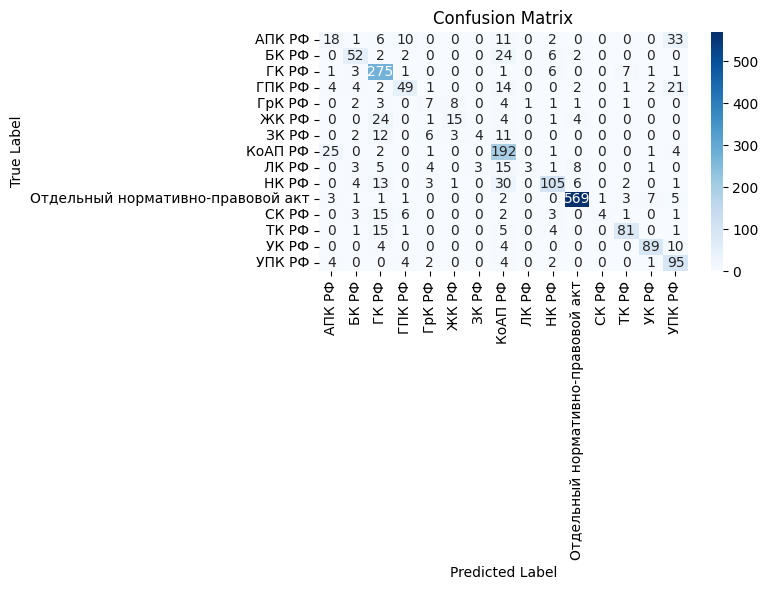


🔍 Отбор документов по стратегии: ENTROPY (batch_size=20)
✅ Выбрано 20 документов для разметки
  • Средний score: 2.7035
  • Диапазон scores: [2.7028, 2.7050]

📝 Топ-3 выбранных документа:

  1. Score=2.7050
     Статья 124. Форма и содержание заявления о вынесении судебного приказа         Статья 124. Форма и содержание заявления о вынесении судебного приказа ...

  2. Score=2.7043
     Статья 127. Содержание судебного приказа         Статья 127. Содержание судебного приказа   См. комментарии к статье 127 ГПК РФ   1. В судебном приказ...

  3. Score=2.7043
     Статья 106. Установление, изменение, прекращение существования зон с особыми условиями использования территорий         Статья 106. Установление, изм...

✅ Добавлено 20 новых документов
📊 Текущий размер размеченного датасета: 70

📊 Распределение классов:
  • Отдельный нормативно-правовой акт: 14 (20.0%)
  • ГК РФ: 8 (11.4%)
  • ЛК РФ: 8 (11.4%)
  • ЗК РФ: 7 (10.0%)
  • КоАП РФ: 5 (7.1%)
  • НК РФ: 4 (5.7%)
  • ГПК РФ: 4 (5.7%)

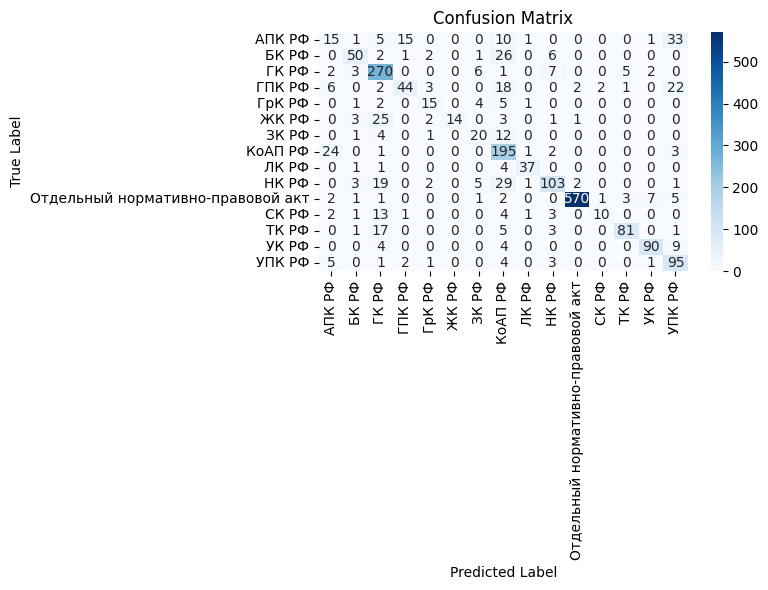


🔍 Отбор документов по стратегии: ENTROPY (batch_size=20)
✅ Выбрано 20 документов для разметки
  • Средний score: 2.7046
  • Диапазон scores: [2.7040, 2.7056]

📝 Топ-3 выбранных документа:

  1. Score=2.7056
     Статья 178.1. Требования к руководителю регионального оператора, кандидату на должность руководителя регионального оператора          Информация об из...

  2. Score=2.7053
     Статья 157.2. Предоставление коммунальных услуг ресурсоснабжающей организацией, региональным оператором по обращению с твердыми коммунальными отхода...

  3. Score=2.7053
     Статья 143. Членство в товариществе собственников жилья         Статья 143. Членство в товариществе собственников жилья   См. Энциклопедии и другие ко...

✅ Добавлено 20 новых документов
📊 Текущий размер размеченного датасета: 90

📊 Распределение классов:
  • ЖК РФ: 15 (16.7%)
  • Отдельный нормативно-правовой акт: 14 (15.6%)
  • ГК РФ: 9 (10.0%)
  • ЛК РФ: 8 (8.9%)
  • ЗК РФ: 7 (7.8%)
  • КоАП РФ: 6 (6.7%)
  • НК РФ: 5 (5.6%)


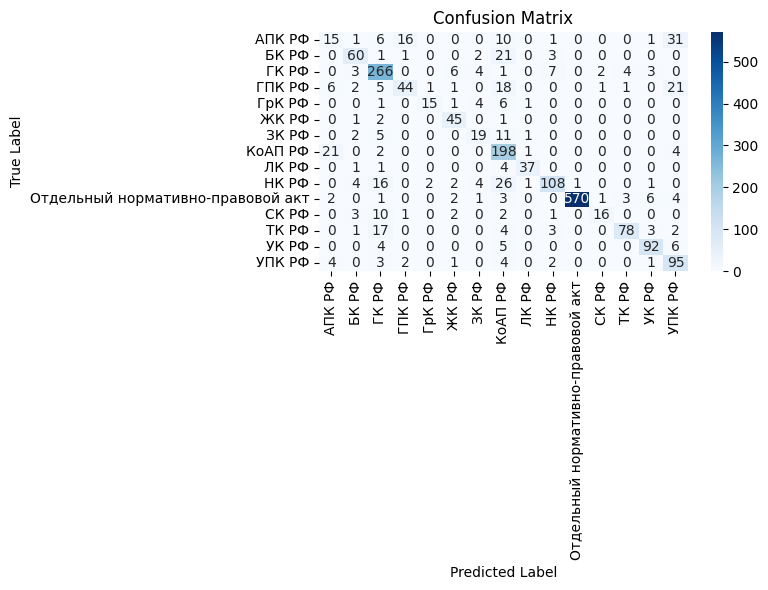


🔍 Отбор документов по стратегии: ENTROPY (batch_size=20)
✅ Выбрано 20 документов для разметки
  • Средний score: 2.7061
  • Диапазон scores: [2.7059, 2.7063]

📝 Топ-3 выбранных документа:

  1. Score=2.7063
     Статья 90. Основания и порядок освобождения от уплаты государственной пошлины, уменьшения ее размера, предоставления отсрочки или рассрочки уплаты го...

  2. Score=2.7063
     Статья 345. Режим рабочего времени лиц, работающих в религиозных организациях         Статья 345. Режим рабочего времени лиц, работающих в религиозных...

  3. Score=2.7062
     Статья 28. Предъявление иска по месту жительства или адресу ответчика          Информация об изменениях: Статья 28 изменена с 1 октября 2019 г. - Феде...

✅ Добавлено 20 новых документов
📊 Текущий размер размеченного датасета: 110

📊 Распределение классов:
  • ЖК РФ: 15 (13.6%)
  • Отдельный нормативно-правовой акт: 14 (12.7%)
  • ГПК РФ: 10 (9.1%)
  • ГК РФ: 9 (8.2%)
  • СК РФ: 9 (8.2%)
  • НК РФ: 9 (8.2%)
  • ЛК РФ: 8 (7.3%)


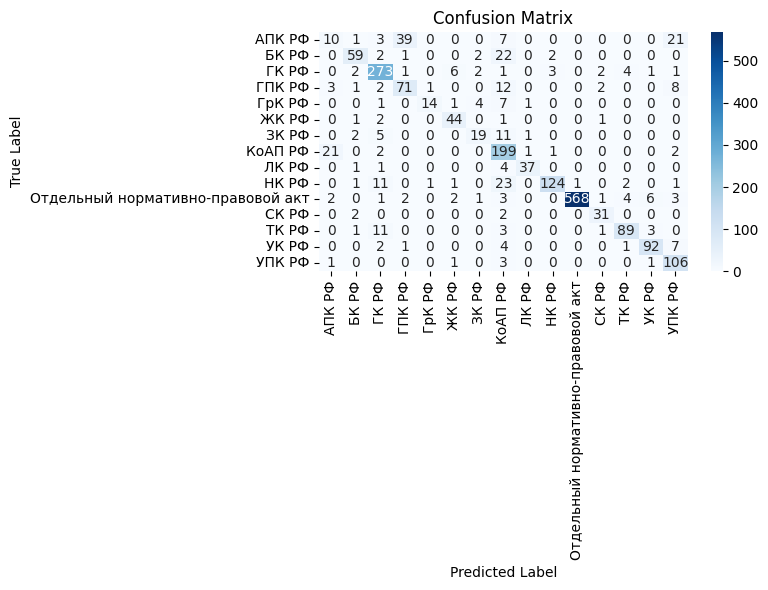


🔍 Отбор документов по стратегии: ENTROPY (batch_size=20)
✅ Выбрано 20 документов для разметки
  • Средний score: 2.7051
  • Диапазон scores: [2.7047, 2.7061]

📝 Топ-3 выбранных документа:

  1. Score=2.7061
     Статья 267.1. Методы осуществления государственного (муниципального) финансового контроля          Информация об изменениях: Федеральным законом от 23...

  2. Score=2.7057
     Статья 31.12. Порядок использования документов, изготовленных в электронном виде, в том числе в форме электронного документа, при исполнении администр...

  3. Score=2.7056
     Статья 121.2. Виды государственных (муниципальных) ценных бумаг и их выпуск         Статья 121.2. Виды государственных (муниципальных) ценных бумаг и ...

✅ Добавлено 20 новых документов
📊 Текущий размер размеченного датасета: 130

📊 Распределение классов:
  • Отдельный нормативно-правовой акт: 16 (12.3%)
  • ЖК РФ: 16 (12.3%)
  • ГК РФ: 11 (8.5%)
  • ЛК РФ: 11 (8.5%)
  • ГПК РФ: 10 (7.7%)
  • НК РФ: 10 (7.7%)
  • КоАП РФ: 9 (6

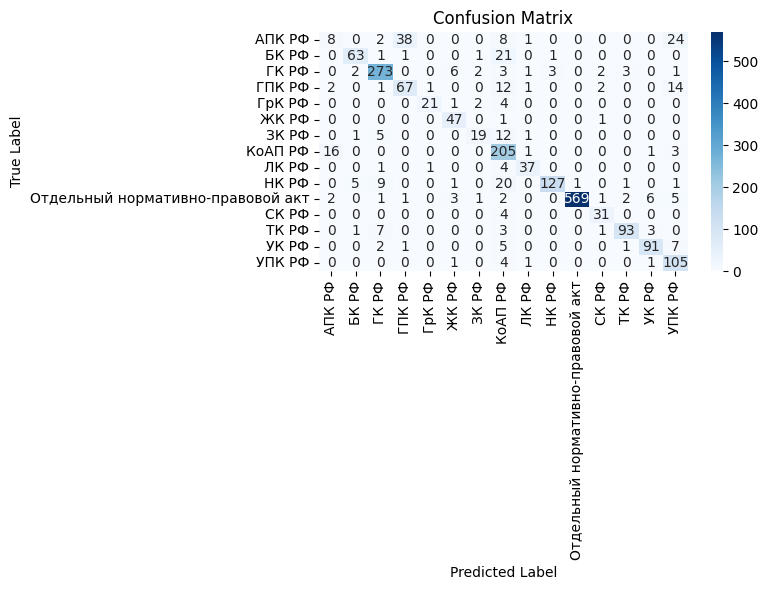

In [5]:
agent_entropy = ActiveLearningAgent(model_type='logreg', random_state=42)

history_entropy = agent_entropy.run_cycle(
    labeled_df=df_labeled_init,
    pool_df=df_pool,
    test_df=df_test,
    strategy='entropy',
    n_iterations=5,
    batch_size=20,
    text_column=TEXT_COL,
    label_column=LABEL_COL
)

In [6]:
# Результаты entropy
df_entropy = pd.DataFrame([vars(m) for m in history_entropy])
df_entropy[['iteration', 'n_labeled', 'accuracy', 'f1']]

,iteration,n_labeled,accuracy,f1
0,1,50,0.753021,0.733100
1,2,70,0.777670,0.769402
2,3,90,0.801353,0.795726
3,4,110,0.839053,0.833413
4,5,130,0.848719,0.842346


## 3. AL-цикл: Random стратегия (baseline)


🚀 ЗАПУСК ЦИКЛА АКТИВНОГО ОБУЧЕНИЯ ДЛЯ ЮРИДИЧЕСКИХ ДОКУМЕНТОВ
   Стратегия: RANDOM
   Итераций: 5
   Batch size: 20

📊 ИТЕРАЦИЯ 1/5

📚 Размеченных документов: 50
📦 Неразмеченных документов: 8224

📚 Обучение модели на 50 размеченных документах...
  • Классы: ['АПК РФ', 'БК РФ', 'ГК РФ', 'ГПК РФ', 'ГрК РФ', 'ЖК РФ', 'ЗК РФ', 'КоАП РФ', 'ЛК РФ', 'НК РФ', 'Отдельный нормативно-правовой акт', 'СК РФ', 'ТК РФ', 'УК РФ', 'УПК РФ']
  • Размерность признаков: 4111

✅ Обучение завершено
  • Accuracy: 1.0000
  • F1-score: 1.0000

📊 Оценка модели на тестовых документах:
  • Accuracy: 0.7530
  • F1-score: 0.7331
  • Precision: 0.7572
  • Recall: 0.7530


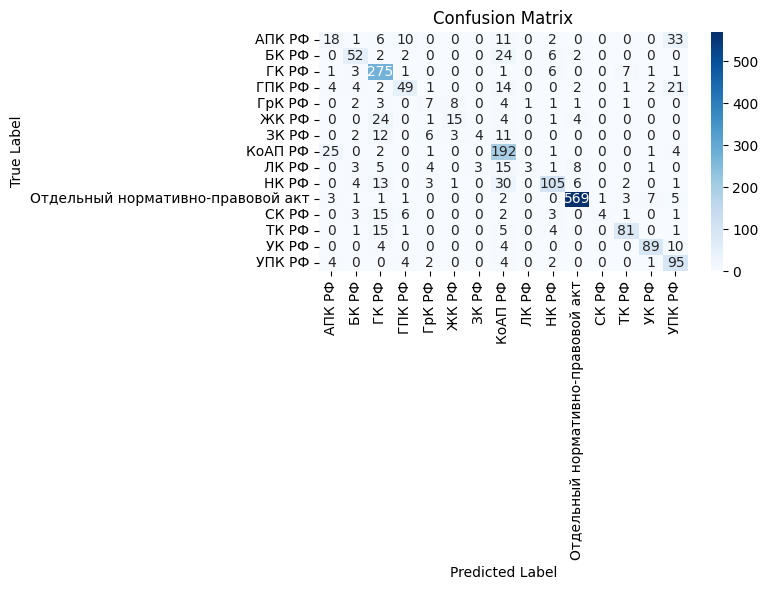


🔍 Отбор документов по стратегии: RANDOM (batch_size=20)
✅ Выбрано 20 документов для разметки
  • Средний score: 0.9984
  • Диапазон scores: [0.9971, 0.9997]

📝 Топ-3 выбранных документа:

  1. Score=0.9997
     Статья 104.5. Порядок определения размера судебного штрафа         Статья 104.5. Порядок определения размера судебного штрафа   См. комментарии к стат...

  2. Score=0.9996
     Статья 15.36. Неисполнение оператором платежной системы требований законодательства Российской Федерации о национальной платежной системе       ...

  3. Score=0.9995
     Зарегистрирован в Минюсте РФ 26 июня 2019 г.  Регистрационный N 55053  В соответствии с частью 5 статьи 36 Федерального закона от 21 ноября 2011 г. N ...

✅ Добавлено 20 новых документов
📊 Текущий размер размеченного датасета: 70

📊 Распределение классов:
  • Отдельный нормативно-правовой акт: 20 (28.6%)
  • ГК РФ: 9 (12.9%)
  • НК РФ: 7 (10.0%)
  • КоАП РФ: 6 (8.6%)
  • УК РФ: 5 (7.1%)
  • ТК РФ: 5 (7.1%)
  • УПК РФ: 3 (4.3%)
 

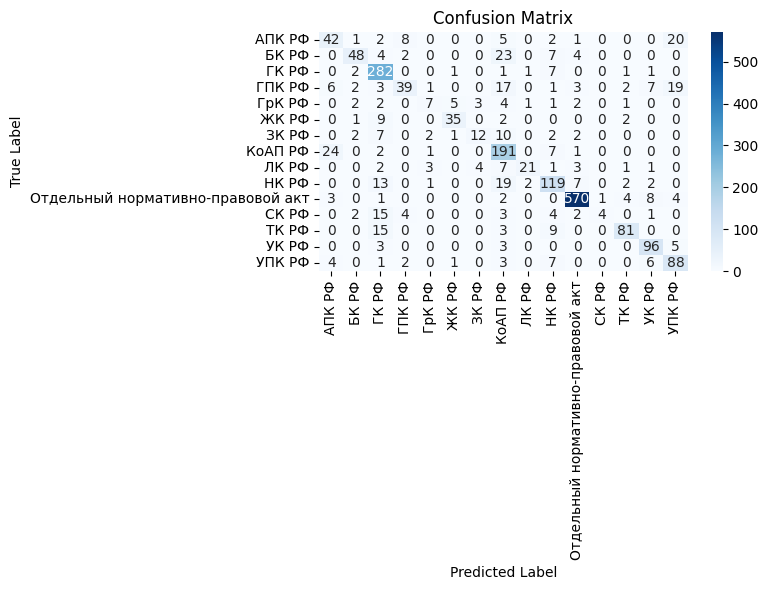


🔍 Отбор документов по стратегии: RANDOM (batch_size=20)


KeyboardInterrupt: 

In [7]:
agent_random = ActiveLearningAgent(model_type='logreg', random_state=42)

history_random = agent_random.run_cycle(
    labeled_df=df_labeled_init,
    pool_df=df_pool,
    test_df=df_test,
    strategy='random',
    n_iterations=5,
    batch_size=20,
    text_column=TEXT_COL,
    label_column=LABEL_COL
)

In [ ]:
# Результаты random
df_random = pd.DataFrame([vars(m) for m in history_random])
df_random[['iteration', 'n_labeled', 'accuracy', 'f1']]

## 4. Сравнение стратегий: кривые обучения на одном графике

In [ ]:
agent_entropy.report(
    history_entropy,
    save_path='../learning_curve_entropy_vs_random.png',
    compare_with=history_random,
    baseline_name='random'
)

In [ ]:
# Детальное сравнение в таблице
comparison = pd.DataFrame({
    'n_labeled': df_entropy['n_labeled'],
    'accuracy_entropy': df_entropy['accuracy'],
    'accuracy_random': df_random['accuracy'],
    'f1_entropy': df_entropy['f1'],
    'f1_random': df_random['f1'],
    'accuracy_diff': df_entropy['accuracy'] - df_random['accuracy'],
    'f1_diff': df_entropy['f1'] - df_random['f1']
})
comparison

## 5. Вывод: экономия примеров

In [ ]:
# Расширенный random (15 итераций) для точной оценки экономии
agent_random_ext = ActiveLearningAgent(model_type='logreg', random_state=42)

history_random_ext = agent_random_ext.run_cycle(
    labeled_df=df_labeled_init,
    pool_df=df_pool,
    test_df=df_test,
    strategy='random',
    n_iterations=15,
    batch_size=20,
    text_column=TEXT_COL,
    label_column=LABEL_COL
)

In [ ]:
# Сколько примеров нужно random для того же accuracy/F1 что и entropy?
final_entropy_acc = df_entropy.iloc[-1]['accuracy']
final_entropy_f1 = df_entropy.iloc[-1]['f1']
final_entropy_n = df_entropy.iloc[-1]['n_labeled']

df_random_ext = pd.DataFrame([vars(m) for m in history_random_ext])

random_at_target = df_random_ext[df_random_ext['accuracy'] >= final_entropy_acc]

print('=== ВЫВОД ===')
print(f'\nEntropy достигает accuracy={final_entropy_acc:.4f} при N={int(final_entropy_n)} документах')

if len(random_at_target) > 0:
    random_n_needed = random_at_target.iloc[0]['n_labeled']
    saved = random_n_needed - final_entropy_n
    print(f'Random достигает того же accuracy при N={int(random_n_needed)} документах')
    print(f'\nЭкономия: {int(saved)} документов ({saved/random_n_needed*100:.1f}%)')
    print(f'Entropy эффективнее в {random_n_needed/final_entropy_n:.1f}x раз')
else:
    print(f'Random НЕ смог достичь accuracy={final_entropy_acc:.4f} даже при N={int(df_random_ext.iloc[-1]["n_labeled"])} документах')
    print('Это подтверждает преимущество entropy-стратегии')

print(f'\n--- F1-score ---')
random_at_target_f1 = df_random_ext[df_random_ext['f1'] >= final_entropy_f1]
print(f'Entropy достигает F1={final_entropy_f1:.4f} при N={int(final_entropy_n)} документах')

if len(random_at_target_f1) > 0:
    random_n_f1 = random_at_target_f1.iloc[0]['n_labeled']
    saved_f1 = random_n_f1 - final_entropy_n
    print(f'Random достигает того же F1 при N={int(random_n_f1)} документах')
    print(f'Экономия: {int(saved_f1)} документов ({saved_f1/random_n_f1*100:.1f}%)')
else:
    print(f'Random НЕ смог достичь F1={final_entropy_f1:.4f} даже при N={int(df_random_ext.iloc[-1]["n_labeled"])} документах')

In [ ]:
# Финальный график: entropy vs random (расширенный)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(df_entropy['n_labeled'], df_entropy['accuracy'], 'bo-', lw=2, ms=8, label='Entropy')
ax1.plot(df_random_ext['n_labeled'], df_random_ext['accuracy'], 'r^--', lw=2, ms=6, label='Random')
ax1.axhline(y=final_entropy_acc, color='blue', ls=':', alpha=0.5, label=f'Entropy target ({final_entropy_acc:.3f})')
ax1.set_xlabel('Количество размеченных документов')
ax1.set_ylabel('Accuracy')
ax1.set_title('Кривая обучения (Accuracy)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(df_entropy['n_labeled'], df_entropy['f1'], 'go-', lw=2, ms=8, label='Entropy')
ax2.plot(df_random_ext['n_labeled'], df_random_ext['f1'], 'r^--', lw=2, ms=6, label='Random')
ax2.axhline(y=final_entropy_f1, color='green', ls=':', alpha=0.5, label=f'Entropy target ({final_entropy_f1:.3f})')
ax2.set_xlabel('Количество размеченных документов')
ax2.set_ylabel('F1-score')
ax2.set_title('Кривая обучения (F1-score)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../learning_curve_entropy_vs_random.png', dpi=150, bbox_inches='tight')
plt.show()

print('График сохранен: learning_curve_entropy_vs_random.png')

In [ ]:
# Сохраняем результаты
os.makedirs('../results', exist_ok=True)

df_entropy.to_csv('../results/active_learning_history.csv', index=False)
df_random.to_csv('../results/random_baseline_history.csv', index=False)
df_random_ext.to_csv('../results/random_extended_history.csv', index=False)
comparison.to_csv('../results/strategy_comparison.csv', index=False)

print('Результаты сохранены в results/')